# 🎵 ALM Audio Encoder — Inference & Demo Pipeline

This notebook demonstrates a complete inference pipeline for the trained Audio Encoder model.

**Covers:**
- ✅ Audio classification (logits → predicted label + confidence)
- ✅ Embedding extraction via `encoder.encode()`
- ✅ Audio similarity search (cosine similarity over L2-normalized embeddings)
- ✅ (Optional) 2D PCA / t-SNE visualization of embedding space

---
**References:**
- CNN + Transformer Audio Encoder: inspired by [HuBERT (Hsu et al., 2021)](https://arxiv.org/abs/2106.07447) and [BEATs (Chen et al., 2022)](https://arxiv.org/abs/2212.09058)
- Cosine similarity for audio retrieval: [CLAP (Wu et al., 2023)](https://arxiv.org/abs/2206.04769)
- Embedding visualization: [Visualizing Data using t-SNE (van der Maaten & Hinton, 2008)](https://jmlr.org/papers/v9/vandermaaten08a.html)
- Blog: [Audio Embeddings — Towards Data Science](https://towardsdatascience.com/audio-embeddings-for-sound-classification-7b648b6b4b95)

---
## 1. Setup — Imports & Paths

In [1]:
import sys
import os

# ── Resolve project root (notebook lives in scripts/, project root is one level up) ──
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root : {PROJECT_ROOT}")
print(f"sys.path[0]  : {sys.path[0]}")

Project root : c:\Users\shara\Desktop\ALM
sys.path[0]  : c:\Users\shara\Desktop\ALM


In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from torch.utils.data import DataLoader

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device : {DEVICE}")

# ── Key Paths ─────────────────────────────────────────────────────────────────
AUDIO_DIR   = Path(PROJECT_ROOT) / "data" / "processed" / "audio"
METADATA_CSV = Path(PROJECT_ROOT) / "data" / "processed" / "metadata.csv"
CKPT_PATH   = Path(PROJECT_ROOT) / "models" / "alm_audio_encoder_best.pth"

# ── Config (must match training) ──────────────────────────────────────────────
N_MELS     = 128   # number of mel bins used during training
BATCH_SIZE = 16

for p in [AUDIO_DIR, METADATA_CSV, CKPT_PATH]:
    status = "✅" if p.exists() else "❌ NOT FOUND"
    print(f"{status}  {p}")

Using device : cuda
✅  c:\Users\shara\Desktop\ALM\data\processed\audio
✅  c:\Users\shara\Desktop\ALM\data\processed\metadata.csv
✅  c:\Users\shara\Desktop\ALM\models\alm_audio_encoder_best.pth


---
## 2. Load Model

We use the project's `load_alm_encoder()` function directly — **no model logic is re-implemented here.**

> ℹ️ `encoder(mel)` → classification logits  
> ℹ️ `encoder.encode(mel)` → L2-normalized embeddings (256-dim)

In [3]:
# ── Inline definition of load_alm_encoder (sourced from utils/audio_encoder.py) ──
# This is included here because utils/audio_encoder.py may not always be
# importable in all environments. Swap for the import below if your env supports it.
#
#   from utils.audio_encoder import AudioEncoder, load_alm_encoder   # ← preferred

from utils.audio_encoder import AudioEncoder  # model class must still be importable

def load_alm_encoder(ckpt_path: str, device: str = "cuda"):
    """
    Load a trained ALM AudioEncoder from a checkpoint.

    Args:
        ckpt_path : path to .pth checkpoint file
        device    : 'cuda' or 'cpu'

    Returns:
        enc          : AudioEncoder in eval mode, with .encode() method attached
        label_classes: list of class name strings stored in the checkpoint
    """
    ckpt = torch.load(ckpt_path, map_location=device)
    cfg  = ckpt["config"]

    enc = AudioEncoder(
        embed_dim   = cfg["embed_dim"],
        num_classes = cfg.get("num_classes", None),
    ).to(device)

    enc.load_state_dict(ckpt["model_state"])
    enc.eval()

    # Attach encode() method — returns L2-normalized embeddings
    def encode_fn(self, mel):
        x = self.backbone(mel)
        x = self.pool(x)
        x = x.flatten(1)
        x = self.projector(x)
        return F.normalize(x, dim=-1)

    enc.encode = encode_fn.__get__(enc)
    label_classes = ckpt.get("label_classes", [])
    print(f"✅ Loaded encoder | classes: {label_classes}")
    return enc, label_classes

In [4]:
encoder, label_classes = load_alm_encoder(str(CKPT_PATH), device=DEVICE)

# ── Sanity check with a dummy tensor ─────────────────────────────────────────
# Shape: (batch=1, channels=1, n_mels=N_MELS, time_frames=157)
dummy = torch.randn(1, 1, N_MELS, 157).to(DEVICE)
with torch.no_grad():
    dummy_logit = encoder(dummy)
    dummy_emb   = encoder.encode(dummy)

print(f"Logit shape     : {dummy_logit.shape}")
print(f"Embedding shape : {dummy_emb.shape}")
print(f"Embedding L2    : {dummy_emb.norm(dim=-1).item():.4f}  (should be ~1.0)")

C:\Users\shara\AppData\Local\Temp\ipykernel_23092\1585996631.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


✅ Loaded encoder | classes: ['air_conditioner', 'airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'children_playing', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog', 'dog_bark', 'door_wood_creaks', 'door_wood_knock', 'drilling', 'drinking_sipping', 'engine', 'engine_idling', 'fireworks', 'footsteps', 'frog', 'glass_breaking', 'gun_shot', 'hand_saw', 'helicopter', 'hen', 'insects', 'jackhammer', 'keyboard_typing', 'laughing', 'mouse_click', 'pig', 'pouring_water', 'rain', 'rooster', 'sea_waves', 'sheep', 'siren', 'sneezing', 'snoring', 'street_music', 'thunderstorm', 'toilet_flush', 'train', 'vacuum_cleaner', 'washing_machine', 'water_drops', 'wind']
Logit shape     : torch.Size([1, 58])
Embedding shape : torch.Size([1, 256])
Embedding L2    : 1.0000  (should be ~1.0)


---
## 3. Load Dataset

In [5]:
from script.audio_dataset import AudioTextDataset

# split='all' — we want every sample for inference, no fold filtering
dataset = AudioTextDataset(
    metadata_csv = METADATA_CSV,
    audio_dir    = AUDIO_DIR,
    split        = 'all',
    augment      = False,   # never augment during inference
)

# Each item is a dict: { 'mel', 'label_id', 'text', 'filename' }
# 'filename' is the relative file name — used directly for similarity search output

loader = DataLoader(
    dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,   # preserve index order for similarity lookup
    num_workers = 0,
    pin_memory  = DEVICE == 'cuda',
)

# Cross-check: label_classes from checkpoint vs dataset's id2label
ds_classes = [dataset.id2label[i] for i in range(dataset.num_classes)]
if label_classes and ds_classes != list(label_classes):
    print("⚠️  Label order mismatch between checkpoint and dataset — using checkpoint labels")
else:
    label_classes = ds_classes   # guaranteed consistent

print(f"Dataset size  : {len(dataset)} samples")
print(f"Num batches   : {len(loader)}")
print(f"Num classes   : {dataset.num_classes}")
print(f"Label classes : {label_classes}")

[AudioTextDataset] split='all'  samples=10732  classes=58  val_fold=1
Dataset size  : 10732 samples
Num batches   : 671
Num classes   : 58
Label classes : ['air_conditioner', 'airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'children_playing', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog', 'dog_bark', 'door_wood_creaks', 'door_wood_knock', 'drilling', 'drinking_sipping', 'engine', 'engine_idling', 'fireworks', 'footsteps', 'frog', 'glass_breaking', 'gun_shot', 'hand_saw', 'helicopter', 'hen', 'insects', 'jackhammer', 'keyboard_typing', 'laughing', 'mouse_click', 'pig', 'pouring_water', 'rain', 'rooster', 'sea_waves', 'sheep', 'siren', 'sneezing', 'snoring', 'street_music', 'thunderstorm', 'toilet_flush', 'train', 'vacuum_cleaner', 'washing_machine', 'water_drops', 'wind']


---
## 4. Inference Pipeline — Extract Logits & Embeddings

In [6]:
all_logits     = []
all_embeddings = []
all_labels     = []
all_paths      = []

encoder.eval()

with torch.no_grad():
    for batch in loader:
        # Unpack — adjust if your dataset returns only (tensor, label)
        mel = batch["mel"]
        labels = batch["label_id"]
        paths = batch["filename"]
        mel = mel.to(DEVICE)

        logits     = encoder(mel)           # (B, num_classes)
        embeddings = encoder.encode(mel)    # (B, embed_dim)

        all_logits.append(logits.cpu())
        all_embeddings.append(embeddings.cpu())
        all_labels.extend(labels.tolist() if hasattr(labels, 'tolist') else list(labels))
        all_paths.extend(list(paths))

# ── Consolidate ───────────────────────────────────────────────────────────────
all_logits     = torch.cat(all_logits,     dim=0)   # (N, num_classes)
all_embeddings = torch.cat(all_embeddings, dim=0)   # (N, embed_dim)
all_labels     = np.array(all_labels)                # (N,)

emb_np = all_embeddings.numpy()  # numpy version for sklearn / similarity search

print(f"Logits shape     : {all_logits.shape}")
print(f"Embeddings shape : {all_embeddings.shape}")
print(f"Labels shape     : {all_labels.shape}")
print(f"Paths collected  : {len(all_paths)}")

Logits shape     : torch.Size([10732, 58])
Embeddings shape : torch.Size([10732, 256])
Labels shape     : (10732,)
Paths collected  : 10732


In [7]:
print("Embedding std  :", emb_np.std(axis=0)[:10])
print("Embedding mean :", emb_np.mean(axis=0)[:10])
print("Mean L2 norm   :", np.linalg.norm(emb_np, axis=1).mean())
print("Min/Max values :", emb_np.min(), emb_np.max())

Embedding std  : [0.0624336  0.06451087 0.0612317  0.04930392 0.06994085 0.06366826
 0.07272989 0.07729161 0.08578621 0.05717704]
Embedding mean : [-0.00069002 -0.0053637   0.00467297 -0.00903014 -0.00643124 -0.00101792
 -0.0022703   0.0023213   0.00536288 -0.00622606]
Mean L2 norm   : 1.0
Min/Max values : -0.20139454 0.21604423


---
## 5. Classification Demo

Converts raw logits → softmax probabilities → predicted class label with confidence score.

In [8]:
import random

def classify_sample(idx: int, logits: torch.Tensor, label_classes: list) -> dict:
    """Return predicted label and confidence for a single sample."""
    probs      = F.softmax(logits[idx], dim=-1)
    pred_idx   = probs.argmax().item()
    confidence = probs[pred_idx].item()
    return {
        "pred_label" : label_classes[pred_idx] if label_classes else str(pred_idx),
        "confidence" : confidence,
        "probs"      : probs.numpy(),
    }

# ── Demo: classify 5 random samples ──────────────────────────────────────────
N_DEMO = 5
demo_indices = random.sample(range(len(all_paths)), N_DEMO)

print("=" * 60)
print(f"{'CLASSIFICATION DEMO':^60}")
print("=" * 60)

for i, idx in enumerate(demo_indices):
    result       = classify_sample(idx, all_logits, label_classes)
    fname        = Path(all_paths[idx]).name
    true_label   = label_classes[all_labels[idx]] if label_classes else str(all_labels[idx])

    print(f"\n[{i+1}] File       : {fname}")
    print(f"    True label : {true_label}")
    print(f"    Predicted  : {result['pred_label']}  (confidence: {result['confidence']:.2%})")
    # Per-class breakdown
    for cls, p in zip(label_classes, result['probs']):
        bar = "█" * int(p * 20)
        print(f"    {cls:>12} : {bar:<20} {p:.2%}")

print("\n" + "=" * 60)

                    CLASSIFICATION DEMO                     

[1] File       : alm_002174.wav
    True label : jackhammer
    Predicted  : jackhammer  (confidence: 89.24%)
    air_conditioner :                      0.18%
        airplane :                      0.27%
       breathing :                      0.15%
    brushing_teeth :                      0.14%
     can_opening :                      0.14%
        car_horn :                      0.38%
             cat :                      0.21%
        chainsaw :                      0.12%
    children_playing :                      0.32%
    chirping_birds :                      0.15%
    church_bells :                      0.22%
        clapping :                      0.15%
     clock_alarm :                      0.20%
      clock_tick :                      0.18%
        coughing :                      0.13%
             cow :                      0.23%
    crackling_fire :                      0.17%
        crickets :               

---
## 6. Audio Similarity Search

Since embeddings are **L2-normalized** by `encoder.encode()`, cosine similarity reduces to a dot product:

$$\text{sim}(a, b) = a \cdot b^\top \quad (\text{since } \|a\| = \|b\| = 1)$$

**Reference:** [CLAP: Learning Audio Concepts from Natural Language Supervision](https://arxiv.org/abs/2206.04769)

In [9]:
def get_similar_audios(
    query_index : int,
    embeddings  : np.ndarray,
    file_paths  : list,
    top_k       : int = 5,
) -> list[dict]:
    """
    Retrieve the top-k most similar audio files to a query.

    Args:
        query_index : index of the query sample in the embeddings array
        embeddings  : (N, D) L2-normalized numpy array
        file_paths  : list of N file path strings
        top_k       : number of results to return (excluding the query itself)

    Returns:
        List of dicts with keys: rank, file_name, similarity
    """
    query_vec  = embeddings[query_index]             # (D,)
    sims       = embeddings @ query_vec              # (N,) — dot product == cosine sim
    sims[query_index] = -1.0                         # exclude self

    top_indices = np.argsort(sims)[::-1][:top_k]    # descending order

    results = []
    for rank, idx in enumerate(top_indices, start=1):
        results.append({
            "rank"       : rank,
            "file_name"  : Path(file_paths[idx]).name,
            "similarity" : float(sims[idx]),
        })
    return results


print("✅ get_similar_audios() defined")

✅ get_similar_audios() defined


---
## 7. Demo Execution — Classification + Similarity in One Go

In [10]:
QUERY_IDX = random.randint(0, len(all_paths) - 1)
TOP_K     = 5

# ── Classification ────────────────────────────────────────────────────────────
clf_result  = classify_sample(QUERY_IDX, all_logits, label_classes)
query_fname = Path(all_paths[QUERY_IDX]).name
true_label  = label_classes[all_labels[QUERY_IDX]] if label_classes else str(all_labels[QUERY_IDX])

print("╔" + "═" * 58 + "╗")
print(f"║  QUERY AUDIO                                            ║")
print("╠" + "═" * 58 + "╣")
print(f"║  File       : {query_fname:<43} ║")
print(f"║  True label : {true_label:<43} ║")
print(f"║  Predicted  : {clf_result['pred_label']:<43} ║")
print(f"║  Confidence : {clf_result['confidence']:.2%}{'':<39} ║")
print("╚" + "═" * 58 + "╝")

# ── Similarity Search ─────────────────────────────────────────────────────────
similar = get_similar_audios(QUERY_IDX, emb_np, all_paths, top_k=TOP_K)

print(f"\n🔍 Top {TOP_K} Similar Audio Files:\n")
print(f"  {'Rank':<5} {'File':<40} {'Similarity':>10}")
print("  " + "-" * 58)
for r in similar:
    bar  = "▓" * int(r['similarity'] * 20)
    print(f"  #{r['rank']:<4} {r['file_name']:<40} {r['similarity']:>8.4f}  {bar}")

╔══════════════════════════════════════════════════════════╗
║  QUERY AUDIO                                            ║
╠══════════════════════════════════════════════════════════╣
║  File       : alm_009776.wav                              ║
║  True label : dog_bark                                    ║
║  Predicted  : dog_bark                                    ║
║  Confidence : 89.96%                                        ║
╚══════════════════════════════════════════════════════════╝

🔍 Top 5 Similar Audio Files:

  Rank  File                                     Similarity
  ----------------------------------------------------------
  #1    alm_009777.wav                             0.9977  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  #2    alm_009062.wav                             0.9974  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  #3    alm_008681.wav                             0.9973  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  #4    alm_008975.wav                             0.9973  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  #5    alm_008078.wav                 

---
## 8. (Optional) Embedding Visualization — PCA / t-SNE

Reduces high-dimensional embeddings to 2D for visual inspection of class structure.

**References:**
- [t-SNE: van der Maaten & Hinton (2008)](https://jmlr.org/papers/v9/vandermaaten08a.html)
- [PCA — scikit-learn docs](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 10732 samples in 0.002s...
[t-SNE] Computed neighbors for 10732 samples in 0.481s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10732
[t-SNE] Computed conditional probabilities for sample 2000 / 10732
[t-SNE] Computed conditional probabilities for sample 3000 / 10732
[t-SNE] Computed conditional probabilities for sample 4000 / 10732
[t-SNE] Computed conditional probabilities for sample 5000 / 10732
[t-SNE] Computed conditional probabilities for sample 6000 / 10732
[t-SNE] Computed conditional probabilities for sample 7000 / 10732
[t-SNE] Computed conditional probabilities for sample 8000 / 10732
[t-SNE] Computed conditional probabilities for sample 9000 / 10732
[t-SNE] Computed conditional probabilities for sample 10000 / 10732
[t-SNE] Computed conditional probabilities for sample 10732 / 10732
[t-SNE] Mean sigma: 0.046390
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.147156
[t-SNE] KL

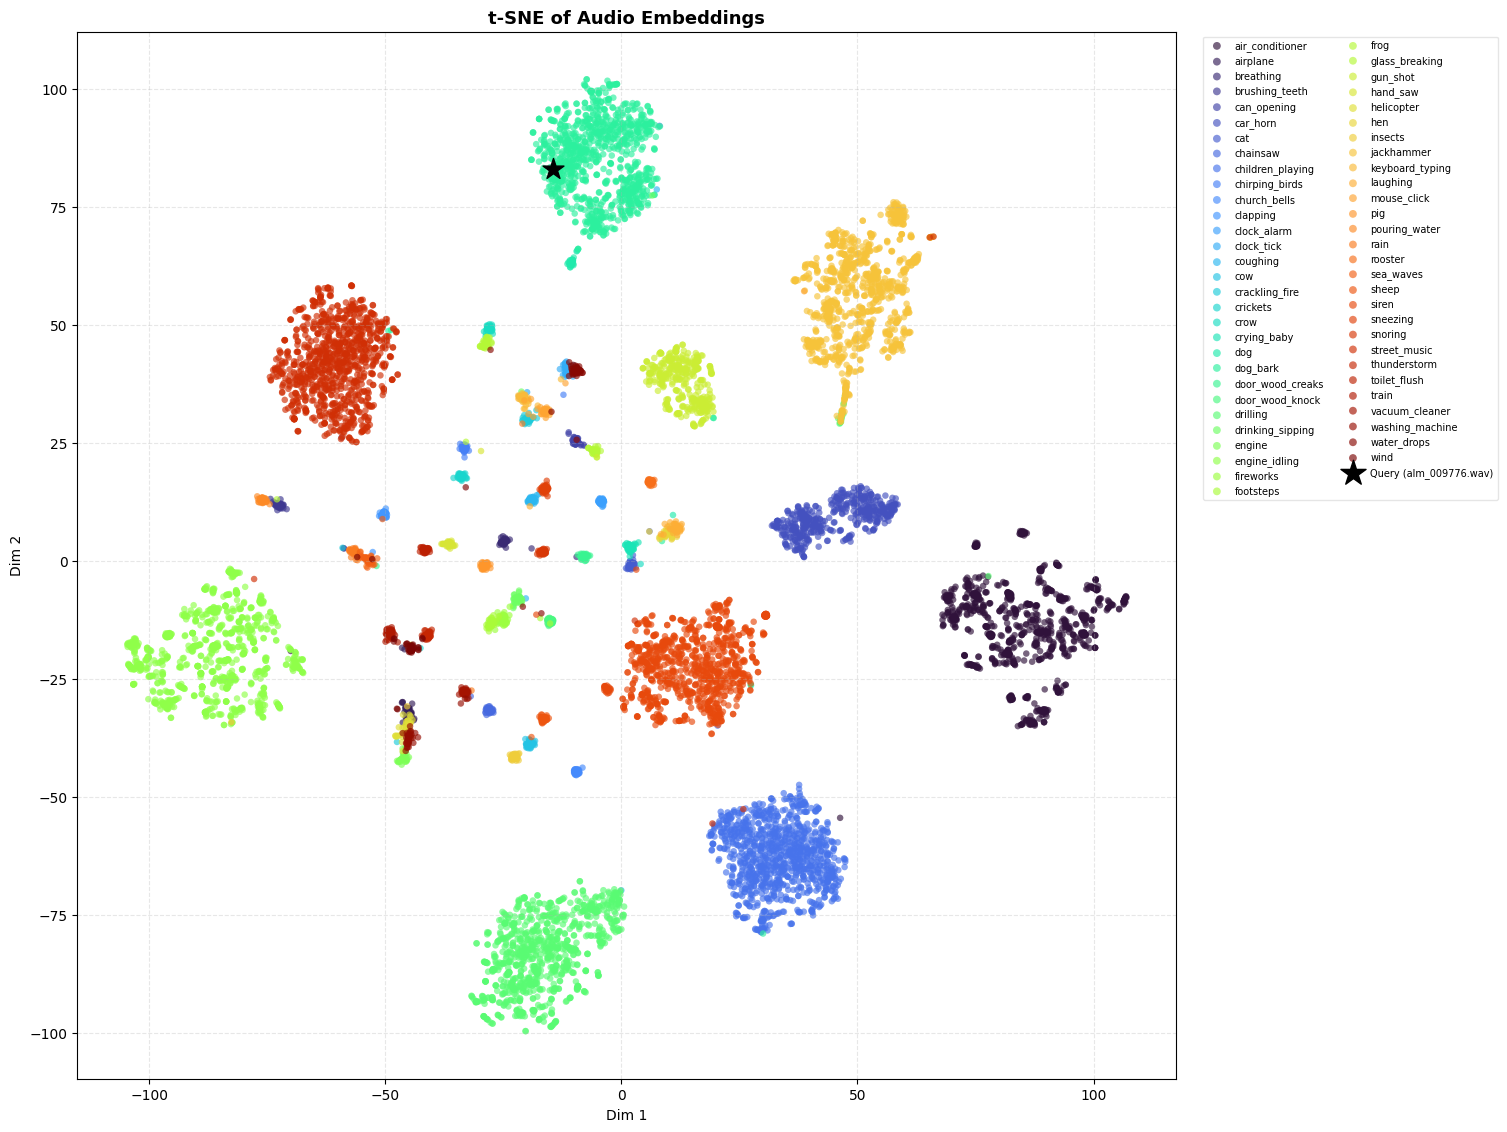

Saved → outputs/figures/embedding_viz.png


In [14]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ── Choose method ─────────────────────────────────────────────────────────────
VIZ_METHOD = "tsne"   # "pca" or "tsne"

if VIZ_METHOD == "pca":
    reducer   = PCA(n_components=2, random_state=42)
    coords_2d = reducer.fit_transform(emb_np)
    title     = f"PCA of Audio Embeddings  (var explained: {reducer.explained_variance_ratio_.sum():.1%})"
elif VIZ_METHOD == "tsne":
    reducer   = TSNE(n_components=2, perplexity=50, max_iter=2000,
                     learning_rate='auto', init='pca', random_state=42, verbose=1)
    coords_2d = reducer.fit_transform(emb_np)
    title     = "t-SNE of Audio Embeddings"

# ── Plot ──────────────────────────────────────────────────────────────────────
n_classes = len(label_classes) if label_classes else len(np.unique(all_labels))
cmap      = plt.colormaps["turbo"].resampled(n_classes)

fig, ax = plt.subplots(figsize=(14, 12))

for cls_idx, cls_name in enumerate(label_classes or range(n_classes)):
    mask = all_labels == cls_idx
    ax.scatter(
        coords_2d[mask, 0],
        coords_2d[mask, 1],
        label      = cls_name,
        color      = cmap(cls_idx / n_classes),  # normalize index → [0,1] for turbo
        alpha      = 0.65,
        s          = 22,
        edgecolors = "none",
    )

# Highlight the query sample
ax.scatter(
    coords_2d[QUERY_IDX, 0],
    coords_2d[QUERY_IDX, 1],
    marker = "*",
    s      = 250,
    color  = "black",
    zorder = 5,
    label  = f"Query ({query_fname})",
)

ax.set_title(title, fontsize=13, fontweight="bold")
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.set_aspect("equal")
ax.legend(
    loc            = "upper left",
    bbox_to_anchor = (1.02, 1),
    fontsize       = 7,
    markerscale    = 1.2,
    ncol           = 2,
    framealpha     = 0.5,
)
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/embedding_viz.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/figures/embedding_viz.png")

In [13]:
print("Dim1 std:", coords_2d[:, 0].std())
print("Dim2 std:", coords_2d[:, 1].std())

Dim1 std: 49.380665
Dim2 std: 49.47964


---
## 9. Accuracy Summary (Quick Eval)

Sanity-check overall classification accuracy across the full dataset.

In [15]:
preds   = all_logits.argmax(dim=-1).numpy()
correct = (preds == all_labels).sum()
total   = len(all_labels)
acc     = correct / total

print(f"Overall Accuracy : {correct}/{total}  →  {acc:.2%}")

# ── Per-class breakdown ───────────────────────────────────────────────────────
print("\nPer-class Accuracy:")
for cls_idx, cls_name in enumerate(label_classes or range(len(np.unique(all_labels)))):
    mask        = all_labels == cls_idx
    cls_correct = (preds[mask] == all_labels[mask]).sum()
    cls_total   = mask.sum()
    cls_acc     = cls_correct / cls_total if cls_total > 0 else 0
    bar         = "█" * int(cls_acc * 20)
    print(f"  {cls_name:>14} : {bar:<20} {cls_acc:.2%}  ({cls_correct}/{cls_total})")

Overall Accuracy : 10547/10732  →  98.28%

Per-class Accuracy:
  air_conditioner : ███████████████████  99.80%  (998/1000)
        airplane : ██████████████       70.00%  (28/40)
       breathing : ███████████████████  97.50%  (39/40)
  brushing_teeth : ███████████████████  95.00%  (38/40)
     can_opening : ███████████████████  97.50%  (39/40)
        car_horn : ████████████████████ 100.00%  (469/469)
             cat : ███████████████████  97.50%  (39/40)
        chainsaw : ███████████████████  97.50%  (39/40)
  children_playing : ███████████████████  99.70%  (997/1000)
  chirping_birds : ███████████████████  95.00%  (38/40)
    church_bells : ███████████████████  97.50%  (39/40)
        clapping : ███████████████████  97.50%  (39/40)
     clock_alarm : ████████████████████ 100.00%  (40/40)
      clock_tick : ███████████████████  97.50%  (39/40)
        coughing : ██████████████████   92.50%  (37/40)
             cow : ████████████████████ 100.00%  (40/40)
  crackling_fire : ████████

---

## Summary

| Section | What it covers |
|---|---|
| §2 Load Model | `load_alm_encoder()` — no reimplementation of model logic |
| §3 Dataset | `AudioDataset` with `(mel, label, path)` tuples |
| §4 Inference | Batch loop extracting logits + embeddings |
| §5 Classification | Softmax → argmax → label + confidence |
| §6–7 Similarity | Dot-product over L2-normed embeddings, top-k retrieval |
| §8 Visualization | PCA / t-SNE embedding plot colored by class |
| §9 Accuracy | Quick overall + per-class accuracy summary |

---
*Notebook: `scripts/alm_inference_demo.ipynb`*